In [33]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
import mapclassify
from shapely import Polygon
import shapely
import contextily
from shapely.geometry import box
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

In [18]:
NOTEBOOK_PATH = Path().resolve()
DATA_DIR = NOTEBOOK_PATH / 'data'
MAPS_DIR = NOTEBOOK_PATH / "maps"
ASSETS_DIR =  NOTEBOOK_PATH / "assets"
MAPS_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

In [19]:
mobility_gdf = gpd.read_file(DATA_DIR / "erasmus_mobility_datasets.gpkg", layer='2018_student_mobility_NUTS2')
mobility_gdf.head()

,OD_ID,ORIGIN,DESTINATION,geometry
0,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
1,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
2,AL01_ITG2,AL01,ITG2,"LINESTRING (5147813.725 2147741.583, 4237843.6..."
3,AL02_AT31,AL02,AT31,"LINESTRING (5166646.306 2059058.198, 4616056.5..."
4,AL02_DE12,AL02,DE12,"LINESTRING (5166646.306 2059058.198, 4224282.2..."


In [20]:
europe_gdf = gpd.read_file(DATA_DIR / "europe_borders.zip").to_crs(mobility_gdf.crs)
europe_gdf.head()

,GID_0,COUNTRY,geometry
0,ALB,Albania,"MULTIPOLYGON (((5185353.594 1901653.12, 518399..."
1,BEL,Belgium,"MULTIPOLYGON (((3992762.882 2941912.743, 39926..."
2,BGR,Bulgaria,"MULTIPOLYGON (((5583297.05 2151545.861, 558324..."
3,HRV,Croatia,"MULTIPOLYGON (((4878690.154 2207591.579, 48787..."
4,CYP,Cyprus,"MULTIPOLYGON (((6466798.95 1664346.442, 646742..."


In [21]:
starts = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[0])))
ends   = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[-1])))

starts_in = gpd.sjoin(starts, europe_gdf, predicate="within")
ends_in   = gpd.sjoin(ends, europe_gdf, predicate="within")

valid_ids = set(starts_in.index) & set(ends_in.index)

mobility_europe = mobility_gdf.loc[list(valid_ids)]

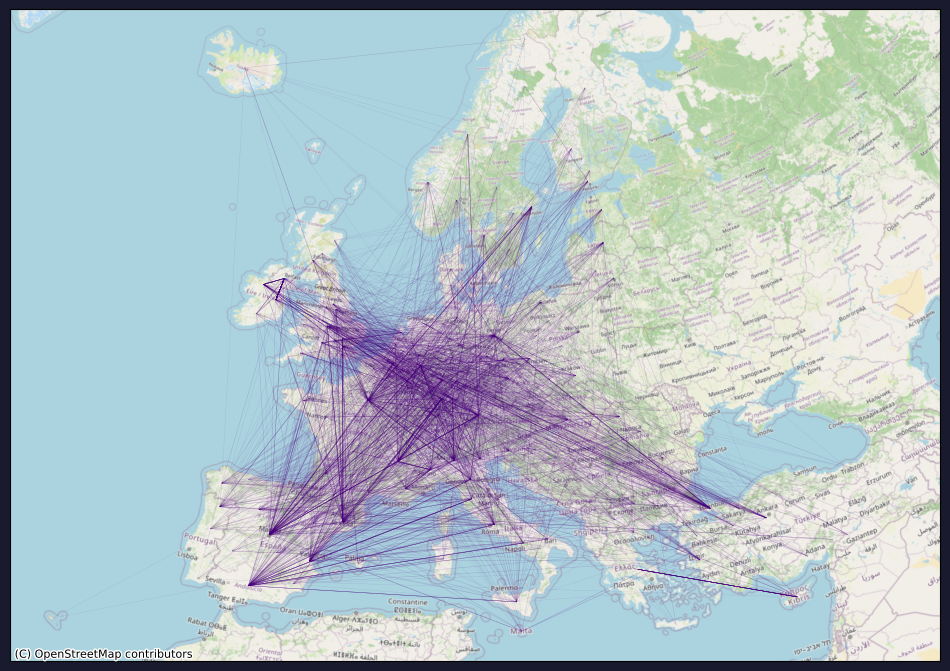

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='#1a1a2e')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

mobility_europe.plot(ax = ax, color="indigo", linewidth=0.3, alpha=0.1)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=5,
    alpha=1
)

# plt.savefig(ASSETS_DIR / "exploratory_map.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [31]:
mobility_europe["length_km"] = mobility_europe.geometry.length / 1000

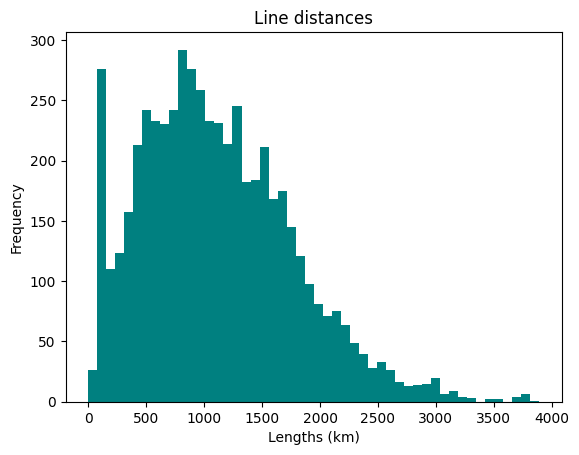

In [ ]:
plt.hist(mobility_europe["length_km"], color="teal", bins=50)
plt.xlabel("Lengths (km)")
plt.ylabel("Frequency")
plt.title("Line distances")

# plt.savefig(ASSETS_DIR / "distances_hist.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

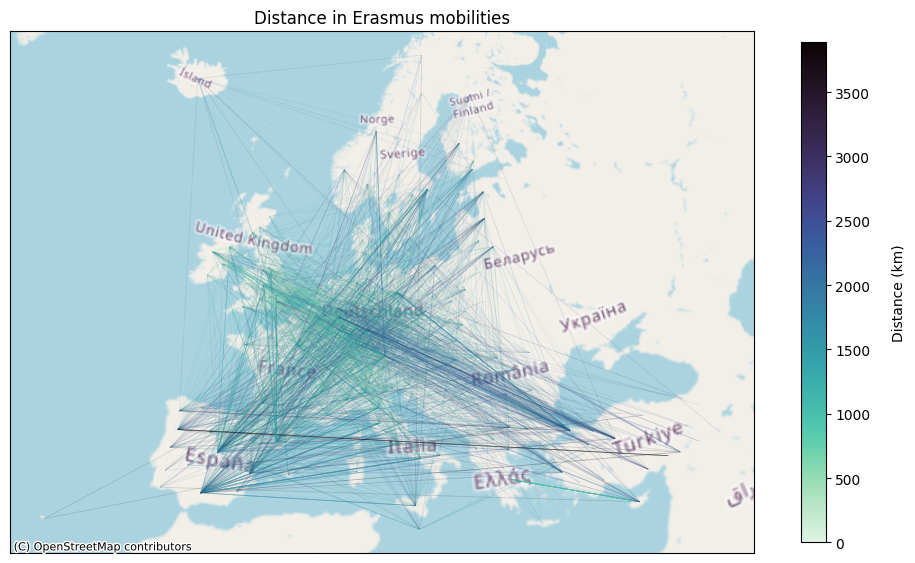

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='white')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

vals = mobility_europe["length_km"]
vals = vals.clip(lower=1e-6)
vmin, vmax = vals.min(), vals.max()
alphas = 0.05 + (vals - vmin) / (vmax - vmin) * (0.15 - 0.05)

norm = (vals - vals.min()) / (vals.max() - vals.min())
lw = 0.1 + (norm ** 0.2) * (0.6 - 0.1) 

mobility_europe.plot(
    ax = ax,
    column="length_km",
    cmap=sns.color_palette("mako_r", as_cmap=True),
    linewidth=lw,
    alpha=alphas,
    legend=True,
    legend_kwds={ "shrink": 0.5}
)
cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Distance (km)", rotation=90, labelpad=15)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=3,
    alpha=1
)

plt.title("Distance in Erasmus mobilities")
# plt.savefig(MAPS_DIR / "distances_km.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()